Primero, se cargan los archivos generados como resultado del preprocesamiento del modelo.

Dado que los archivos se encuentran almacenados en Google Drive. Tenemos que importar lo necesario para montar google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Aquí accederemos a los archivos con la respectiva ruta. Se anexan las rutas como las siguientes.Aqui se tiene que modificar la ruta según sea donde estén almacenados los datos.


In [ ]:
tomIoTgeneradocaracteristicasoriginales = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Ton-IoT-Complete.csv'


---


Se abre el archivo con ayuda de la libreria Pandas y se elimina la feature label para evitar problemas, ya que esta es muy significativa para los modelos por que indica el tipo de trafico que efectua.

---




In [ ]:
import pandas as pd
df = pd.read_csv(tomIoTgeneradocaracteristicasoriginales)


deleted = 'label'
df = df.drop(deleted,axis=1)
#print(df.head())



Se verifica la proporcion entre el tráfico. Esta debería ser dado el caso de TON-IOT de

1.   300 000 DATOS BENIGNOS
2.   161 043 DATOS MALIGNOS



In [ ]:
print(df['category'].value_counts())

category
0    300000
1    161043
Name: count, dtype: int64


---


Se realiza una selección de caracteristicas para utilizar unicamente las 10 más relevantes.
Se usa la técnica de Información Mutua.

---


In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler

# Separar características y etiqueta
X = df.drop('category', axis=1)
y = df['category']

# Asegúrate de que todas las columnas sean numéricas
X = X.select_dtypes(include=['int64', 'float64'])

# Normalizar (opcional pero recomendado para mutual information)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar selección con mutual_info_classif
#selector = SelectKBest(score_func=mutual_info_classif, k=20)
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# Ver columnas seleccionadas
selected_features = X.columns[selector.get_support()]
print("Características seleccionadas:")
print(selected_features.tolist())

# Crear un nuevo DataFrame solo con las columnas seleccionadas
dataframe_dataset_selected = df[selected_features.tolist() + ['category']]

#Mejores 10 Features calculadas con MI

# ['duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts',
# 'dst_ip_bytes', 'proto_tcp', 'proto_udp', 'service_dns', 'conn_state_REJ', 'dns_query_Other',
# 'dns_qclass_0', 'dns_qtype_0', 'dns_qtype_Other', 'dns_AA_-', 'dns_RD_-', 'dns_RD_F', 'dns_RA_-', 'dns_rejected_F']

#Mejores 10 features seleccionadas con MI

#['duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'src_ip_bytes', 'dst_ip_bytes', 'proto_tcp', 'proto_udp', 'service_dns', 'conn_state_REJ']

Características seleccionadas:
['duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'src_ip_bytes', 'dst_ip_bytes', 'proto_tcp', 'proto_udp', 'service_dns', 'conn_state_REJ']


---


Una vez ya seleccionadas las características, se da por finalizada la actividad de preprocesamiento del conjunto de datos y este se encuentra listo para ser trabajado.


---


Para continuar, se realizan las actividades de partición. Considerando que se buscan entrenar dos tipos distintos de modelos de aprendizaje(supervisado y no supervisado), se debe hacer los ajustes necesarios para que no existan complicaciones. Aqui se pueden modificar las particiones según sea planteado por cada estudio.


---

Para los modelos supervisados se harán 2 conjuntos(train y test), mientras que para los no supervisados se harán 3 conjuntos(train,test y validate).


---

In [ ]:
# Tráfico benigno (category == 0)
trafico_benigno = dataframe_dataset_selected[dataframe_dataset_selected['category'] == 0]

# Tráfico malicioso (category == 1)
trafico_maligno = dataframe_dataset_selected[dataframe_dataset_selected['category'] == 1]


---

Se realiza la partición para los modelos supervisados.
La proporcion es de



1.  Entrenamiento -> 80%
2.  Evaluación ->    20%



---

In [ ]:
from sklearn.model_selection import train_test_split

# Definir características (X) y etiquetas (y)
features_sup = dataframe_dataset_selected.drop('category', axis=1)
label_sup = dataframe_dataset_selected['category']

# División entrenamiento / prueba con estratificación
features_sup_train, features_testS, label_sup_train, label_sup_test = train_test_split(
    features_sup,label_sup, test_size=0.2, stratify=y, random_state=26
)


---

Para luego ejecutar la partición para los modelos no supervisados.


1.  Entrenamiento -> 60%
2.  Validación -> 20%
3.  Evaluación -> 20%

Hay que considerar igualmente que los modelos no supervisados solo usan datos benignos para ser entrenados.

---

In [ ]:
# Separar benigno y malicioso
df_benigno = dataframe_dataset_selected[dataframe_dataset_selected['category'] == 0]
df_maligno = dataframe_dataset_selected[dataframe_dataset_selected['category'] == 1]

# ------------------ DIVISIÓN BENIGNA ------------------

# 60% entrenamiento, 20% validación, 20% test
benigno_trainNS, benigno_ValTestNS = train_test_split(df_benigno, test_size=0.4, random_state=26)
benigno_valNS, benigno_TestNS = train_test_split(benigno_ValTestNS, test_size=0.5, random_state=19)

# Eliminar la columna 'category' del conjunto de entrenamiento
benigno_trainNS = benigno_trainNS.drop(columns=['category'], errors='ignore')

# ------------------ VALIDACIÓN ------------------

# 20% malicioso para validación
X_maligno_val, malicioso_restante = train_test_split(df_maligno, test_size=0.8, random_state=19)

# Validación: 20% benigno + 20% malicioso
X_valid_unsup = pd.concat([
    benigno_valNS.drop(columns=["category"]),
    X_maligno_val.drop(columns=["category"])
])
y_valid_unsup = pd.Series(
    [0] * len(benigno_valNS) + [1] * len(X_maligno_val),
    name="category"
)

# ------------------ TEST ------------------

# 20% del tráfico malicioso para test
X_maligno_test, _ = train_test_split(df_maligno, test_size=0.8, random_state=42)

# Test final balanceado: 20% benigno + 20% malicioso
X_test_unsup = pd.concat([
    benigno_TestNS.drop(columns=["category"]),
    X_maligno_test.drop(columns=["category"])
])
y_test_unsup = pd.Series(
    [0] * len(benigno_TestNS) + [1] * len(X_maligno_test),
    name="category"
)

In [ ]:
# Este bloque se usa para verificar que las proporciones de trafico para validacion y evaluacion se mantienen, al igual
# que solamente se usa trafico benigno para el entrenamiento

def resumen_conjuntos():
    print("----- RESUMEN DE PARTICIONES -----")
    print(f"Train (solo benigno): {len(benigno_trainNS)} instancias")

    print(f"\nValidación:")
    print(f"  Benigno:  {len(benigno_valNS)}")
    print(f"  Malicioso: {len(X_maligno_val)}")
    total_val = len(X_valid_unsup)
    print(f"  Total:     {total_val}")
    print(f"  Proporción malicioso: {len(X_maligno_val) / total_val:.2%}")

    print(f"\nTest:")
    print(f"  Benigno:  {len(benigno_TestNS)}")
    print(f"  Malicioso: {len(X_maligno_test)}")
    print(f"  Total:     {len(X_test_unsup)}")
    total_test = len(X_test_unsup)
    print(f"  Total:     {total_test}")
    print(f"  Proporción malicioso: {len(X_maligno_test) / total_test:.2%}")

resumen_conjuntos()


----- RESUMEN DE PARTICIONES -----
Train (solo benigno): 180000 instancias

Validación:
  Benigno:  60000
  Malicioso: 32208
  Total:     92208
  Proporción malicioso: 34.93%

Test:
  Benigno:  60000
  Malicioso: 32208
  Total:     92208
  Total:     92208
  Proporción malicioso: 34.93%


---
Con las particiones ya realizadas, ahora se entrenan los modelos. Primero, serán ajustados los hiperparametros. Para ello necesitamos instalar optuna, quien realizará pruebas dentro de un rango de parametros para determinar cual combinacion obtiene los mejores resultados dentro de los intentos.

---

In [ ]:
#Bloque para instalar optuna
!pip install -q optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 4.9 MB/s eta 0:00:00


In [ ]:
#Bloque para craer las funciones que permitiran obtener
#los hiperparametros para los modelos supervisados.

import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,classification_report
)
from sklearn.preprocessing import label_binarize

# Validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=25)

# Función para calcular métricas
def compute_metrics(model, X, y):
    classes = np.unique(y)
    y_bin = label_binarize(y, classes=classes)

    aucs, accs, precs, recalls, f1s = [], [], [], [], []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        accs.append(accuracy_score(y_val, y_pred))
        precs.append(precision_score(y_val, y_pred, average='macro', zero_division=0))
        recalls.append(recall_score(y_val, y_pred, average='macro', zero_division=0))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        if hasattr(model, "predict_proba"):
            try:
                y_proba = model.predict_proba(X_val)
                y_val_bin = label_binarize(y_val, classes=classes)
                auc = roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr')
            except:
                auc = 0.0
        else:
            auc = 0.0
        aucs.append(auc)

    # Retornar promedio de cada métrica
    return {
        "accuracy": np.mean(accs),
        "precision": np.mean(precs),
        "recall": np.mean(recalls),
        "f1": np.mean(f1s),
        "auc": np.mean(aucs)
    }

# Objective para Random Forest
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        class_weight='balanced',
        random_state=42
    )

    scores = compute_metrics(model, features_sup_train.values, label_sup_train.values)
    print(f"Trial {trial.number} - Acc: {scores['accuracy']:.4f}, Prec: {scores['precision']:.4f}, Rec: {scores['recall']:.4f}, F1: {scores['f1']:.4f}, AUC: {scores['auc']:.4f}")

    return scores['f1']

# Objective para Decision Tree
def objective_dt(trial):
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        criterion=criterion,
        class_weight='balanced',
        random_state=42
    )

    scores = compute_metrics(model, features_sup_train.values, label_sup_train.values)
    print(f"Trial {trial.number} - Acc: {scores['accuracy']:.4f}, Prec: {scores['precision']:.4f}, Rec: {scores['recall']:.4f}, F1: {scores['f1']:.4f}, AUC: {scores['auc']:.4f}")

    return scores['f1']



In [ ]:
# Bloque para ejecutar las funciones

study_dt = optuna.create_study(direction="maximize")
study_dt.optimize(objective_dt, n_trials=10)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=10)

print("Mejores hiperparámetros Random Forest:", study_rf.best_params)
print("Mejores hiperparámetros Decision Tree:", study_dt.best_params)


In [ ]:
#Forma incial de evaluar los resultados que estaban obteniendo los modelos.

from sklearn.naive_bayes import GaussianNB
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Random Forest
# ----------------------------------------
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(features_sup_train, label_sup_train)

rf_pred = best_rf.predict(features_testS)
rf_proba = best_rf.predict_proba(features_testS)

rf_acc = accuracy_score(label_sup_test, rf_pred)
rf_prec = precision_score(label_sup_test, rf_pred, average='macro', zero_division=0)
rf_rec = recall_score(label_sup_test, rf_pred, average='macro', zero_division=0)
rf_f1 = f1_score(label_sup_test, rf_pred, average='macro')

classes = np.unique(label_sup_test)
if len(classes) == 2:
    rf_auc = roc_auc_score(label_sup_test, rf_proba[:, 1])
else:
    y_test_bin = label_binarize(label_sup_test, classes=classes)
    rf_auc = roc_auc_score(y_test_bin, rf_proba, average='macro', multi_class='ovr')

print("\n--- Random Forest ---")
print(classification_report(label_sup_test, rf_pred, digits=4))

# ----------------------------------------
# Decision Tree
# ----------------------------------------
best_dt = DecisionTreeClassifier(
    **study_dt.best_params,
    class_weight='balanced',
    random_state=42
)
best_dt.fit(features_sup_train, label_sup_train)

dt_pred = best_dt.predict(features_testS)
dt_proba = best_dt.predict_proba(features_testS)

dt_acc = accuracy_score(label_sup_test, dt_pred)
dt_prec = precision_score(label_sup_test, dt_pred, average='macro', zero_division=0)
dt_rec = recall_score(label_sup_test, dt_pred, average='macro', zero_division=0)
dt_f1 = f1_score(label_sup_test, dt_pred, average='macro')

if len(classes) == 2:
    dt_auc = roc_auc_score(label_sup_test, dt_proba[:, 1])
else:
    y_test_bin = label_binarize(label_sup_test, classes=classes)
    dt_auc = roc_auc_score(y_test_bin, dt_proba, average='macro', multi_class='ovr')

print("\n--- Decision Tree ---")
print(classification_report(label_sup_test, dt_pred, digits=4))

# ----------------------------------------
# Naive Bayes
# ----------------------------------------
nb_model = GaussianNB()
nb_model.fit(features_sup_train, label_sup_train)

nb_pred = nb_model.predict(features_testS)
nb_proba = nb_model.predict_proba(features_testS)

nb_acc = accuracy_score(label_sup_test, nb_pred)
nb_prec = precision_score(label_sup_test, nb_pred, average='macro', zero_division=0)
nb_rec = recall_score(label_sup_test, nb_pred, average='macro', zero_division=0)
nb_f1 = f1_score(label_sup_test, nb_pred, average='macro')

if len(classes) == 2:
    nb_auc = roc_auc_score(label_sup_test, nb_proba[:, 1])
else:
    y_test_bin = label_binarize(label_sup_test, classes=classes)
    nb_auc = roc_auc_score(y_test_bin, nb_proba, average='macro', multi_class='ovr')

print("\n--- Naive Bayes ---")
print(classification_report(label_sup_test, nb_pred, digits=4))

# ----------------------------------------
# Visualización de métricas
# ----------------------------------------

models = ['Random Forest', 'Decision Tree', 'Naive Bayes']
accuracy = [rf_acc, dt_acc, nb_acc]
precision = [rf_prec, dt_prec, nb_prec]
recall = [rf_rec, dt_rec, nb_rec]
f1 = [rf_f1, dt_f1, nb_f1]
auc = [rf_auc, dt_auc, nb_auc]

metrics = [accuracy, precision, recall, f1, auc]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']

for metric, name in zip(metrics, metric_names):
    plt.figure(figsize=(6, 4))
    plt.bar(models, metric)
    plt.title(f'{name} por Modelo')
    plt.ylabel(name)
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


NameError: name 'study_rf' is not defined

In [ ]:
# Bloque para evaluar los modelos supervisados
# Para obtener los resultados dentro de 10 distintas instancias
# De evaluacion.

import time

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

# Modelos supervisados
model_constructors = {
    "Random Forest": lambda:RandomForestClassifier(
        n_estimators=204,
        max_depth=10,
        max_features='log2',
        class_weight='balanced',
        random_state=42
    ),
    "Decision Tree":lambda:DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        criterion='log_loss',
        class_weight='balanced',
        random_state=42
    ),
    "Naive Bayes":lambda:GaussianNB()
}
# Convertir a arrays
X = features_sup.values
y = label_sup.values

# Almacenar resultados
wide_format_results = []

for i in range(10):
    print(f"\n--- Iteración {i+1}/10 ---")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42 + i
    )

    row = {}
    for name, constructor in model_constructors.items():
        model = constructor()

        # Tiempo de entrenamiento
        start_train = time.time()
        model.fit(X_train, y_train)
        end_train = time.time()
        train_time = end_train - start_train

        # Tiempo de predicción
        start_pred = time.time()
        y_pred = model.predict(X_test)
        end_pred = time.time()
        predict_time = end_pred - start_pred

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1s = f1_score(y_test, y_pred, average='macro')

        # Calcular AUC si es posible
        if hasattr(model, "predict_proba"):
            try:
                y_proba = model.predict_proba(X_test)
                classes = np.unique(y_test)

                if len(classes) == 2:
                    class_index = list(model.classes_).index(classes[1])
                    auc_ = roc_auc_score(y_test, y_proba[:, class_index])
                else:
                    y_test_bin = label_binarize(y_test, classes=classes)
                    y_proba_bin = y_proba[:, [list(model.classes_).index(c) for c in classes]]
                    auc_ = roc_auc_score(y_test_bin, y_proba_bin, average='macro', multi_class='ovr')
            except Exception as e:
                print(f"AUC no calculable para {name}: {e}")
                auc_ = 0.0
        else:
            auc_ = 0.0

        # Calcular matriz de confusión para clase binaria
        if len(np.unique(y_test)) == 2:
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        else:
            tn = fp = fn = tp = np.nan

        # Guardar resultados
        row[f'accuracy_{name}'] = acc
        row[f'precision_{name}'] = prec
        row[f'recall_{name}'] = rec
        row[f'f1_score_{name}'] = f1s
        row[f'auc_{name}'] = auc_
        row[f'TP_{name}'] = tp
        row[f'TN_{name}'] = tn
        row[f'FP_{name}'] = fp
        row[f'FN_{name}'] = fn
        row[f'train_time_{name}'] = train_time
        row[f'predict_time_{name}'] = predict_time

    wide_format_results.append(row)

# Crear DataFrame
df_sup_wide = pd.DataFrame(wide_format_results)

# Guardar CSV
csv_path = "/content/resultados_supervisados_completo_medidas_temporales.csv"
df_sup_wide.to_csv(csv_path, index=False)

# Descargar si estás en Colab
from google.colab import files
files.download(csv_path)




--- Iteración 1/10 ---

--- Iteración 2/10 ---

--- Iteración 3/10 ---

--- Iteración 4/10 ---

--- Iteración 5/10 ---

--- Iteración 6/10 ---

--- Iteración 7/10 ---

--- Iteración 8/10 ---

--- Iteración 9/10 ---

--- Iteración 10/10 ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

# ==============================
# MODELOS SUPERVISADOS
# ==============================
model_constructors = {
    "Random Forest": lambda: RandomForestClassifier(
        n_estimators=171, max_depth=28, max_features='sqrt',
        class_weight='balanced', random_state=42
    ),
    "Decision Tree": lambda: DecisionTreeClassifier(
        max_depth=30, min_samples_split=9, criterion='gini',
        class_weight='balanced', random_state=42
    ),
    "Naive Bayes": lambda: GaussianNB()
}

# Convertir a arrays
X = features_sup.values
y = label_sup.values

wide_format_results = []

# ==============================
# CICLO EXTERNO: 10 ITERACIONES (80/20)
# ==============================
for iteration in range(10):
    print(f"\n=== Iteración externa {iteration+1}/10 ===")

    # División externa 80/20
    X_train_full, X_eval, y_train_full, y_eval = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42 + iteration
    )

    # Validación cruzada interna con 5 pliegues
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42 + iteration)
    internal_metrics = {name: [] for name in model_constructors.keys()}

    start_iter = time.time()

    # ==============================
    # CICLO INTERNO: VALIDACIÓN (10 folds)
    # ==============================
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_full, y_train_full), 1):
        X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

        for name, constructor in model_constructors.items():
            model = constructor()

            t0 = time.time()
            model.fit(X_train, y_train)
            t1 = time.time()

            y_pred = model.predict(X_val)
            t2 = time.time()

            acc = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
            rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1s = f1_score(y_val, y_pred, average='macro')
            mcc = matthews_corrcoef(y_val, y_pred)

            auc_ = 0.0
            if hasattr(model, "predict_proba"):
                try:
                    y_proba = model.predict_proba(X_val)
                    classes = np.unique(y_val)
                    if len(classes) == 2:
                        class_index = list(model.classes_).index(classes[1])
                        auc_ = roc_auc_score(y_val, y_proba[:, class_index])
                    else:
                        y_val_bin = label_binarize(y_val, classes=classes)
                        y_proba_bin = y_proba[:, [list(model.classes_).index(c) for c in classes]]
                        auc_ = roc_auc_score(y_val_bin, y_proba_bin, average='macro', multi_class='ovr')
                except Exception:
                    pass

            internal_metrics[name].append({
                'accuracy': acc, 'precision': prec, 'recall': rec,
                'f1_score': f1s, 'auc': auc_, 'mcc': mcc,
                'train_time': t1 - t0, 'predict_time': t2 - t1
            })

    # ==============================
    # EVALUACIÓN EXTERNA FINAL
    # ==============================
    row = {"iteracion": iteration + 1}

    for name, constructor in model_constructors.items():
        model = constructor()

        # Entrenamiento final (80%)
        t_train_start = time.time()
        model.fit(X_train_full, y_train_full)
        t_train_end = time.time()

        # Evaluación externa (20%)
        t_pred_start = time.time()
        y_pred_ext = model.predict(X_eval)
        t_pred_end = time.time()

        # Métricas externas
        acc_ext = accuracy_score(y_eval, y_pred_ext)
        prec_ext = precision_score(y_eval, y_pred_ext, average='macro', zero_division=0)
        rec_ext = recall_score(y_eval, y_pred_ext, average='macro', zero_division=0)
        f1s_ext = f1_score(y_eval, y_pred_ext, average='macro')
        mcc_ext = matthews_corrcoef(y_eval, y_pred_ext)

        # AUC externo
        auc_ext = 0.0
        if hasattr(model, "predict_proba"):
            try:
                y_proba_ext = model.predict_proba(X_eval)
                classes = np.unique(y_eval)
                if len(classes) == 2:
                    class_index = list(model.classes_).index(classes[1])
                    auc_ext = roc_auc_score(y_eval, y_proba_ext[:, class_index])
                else:
                    y_eval_bin = label_binarize(y_eval, classes=classes)
                    y_proba_bin = y_proba_ext[:, [list(model.classes_).index(c) for c in classes]]
                    auc_ext = roc_auc_score(y_eval_bin, y_proba_bin, average='macro', multi_class='ovr')
            except Exception:
                pass

        # Matriz de confusión
        cm = confusion_matrix(y_eval, y_pred_ext)
        if cm.shape == (2, 2):  # Solo si es binario
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = fp = fn = tp = np.nan

        # Guardar métricas válidas (evaluación externa)
        row.update({
            f"eval_accuracy_{name}": acc_ext,
            f"eval_precision_{name}": prec_ext,
            f"eval_recall_{name}": rec_ext,
            f"eval_f1_{name}": f1s_ext,
            f"eval_auc_{name}": auc_ext,
            f"eval_mcc_{name}": mcc_ext,
            f"train_time_{name}": t_train_end - t_train_start,
            f"predict_time_{name}": t_pred_end - t_pred_start,
            f"TP_{name}": tp,
            f"TN_{name}": tn,
            f"FP_{name}": fp,
            f"FN_{name}": fn
        })

    end_iter = time.time()
    row["tiempo_total_iteracion"] = end_iter - start_iter

    wide_format_results.append(row)

# ==============================
# RESULTADOS FINALES (10 FILAS)
# ==============================
df_sup_wide = pd.DataFrame(wide_format_results)

# Guardar CSV
csv_path = "/content/resultados_supervisados_final_con_matriz_confusion.csv"
df_sup_wide.to_csv(csv_path, index=False)

from google.colab import files
files.download(csv_path)



=== Iteración externa 1/10 ===

=== Iteración externa 2/10 ===

=== Iteración externa 3/10 ===

=== Iteración externa 4/10 ===

=== Iteración externa 5/10 ===

=== Iteración externa 6/10 ===

=== Iteración externa 7/10 ===

=== Iteración externa 8/10 ===

=== Iteración externa 9/10 ===

=== Iteración externa 10/10 ===


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Unir todos los resultados
all_metrics_df = pd.concat({
    metric: df_results[metric]
    for metric in df_results
}, axis=1)

# Aplanar columnas múltiples
all_metrics_df.columns = ['_'.join(col).strip() for col in all_metrics_df.columns.values]

# Guardar CSV
csv_path = "/content/resultados_crossval_modelos.csv"
all_metrics_df.to_csv(csv_path, index=False)

print(f"Archivo guardado en: {csv_path}")

Archivo guardado en: /content/resultados_crossval_modelos.csv


In [ ]:
from google.colab import files
files.download("/content/resultados_crossval_modelos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Se realiza la misma actividad para los Modelos no Supervisados

In [ ]:
#Bloque para generar las funciones necesarias para evaluar los modelos

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
import optuna
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# ------------------------------
# Función compuesta de score
def composite_score(precision, recall, f1, alpha=0.33, beta=0.33, gamma=0.33):
    return alpha * precision + beta * recall + gamma * f1

# ------------------------------
# Validación segura para AUC (si se desea usar después)
def safe_roc_auc_score(y_true, y_pred):
    try:
        return roc_auc_score(y_true, y_pred)
    except:
        return 0.0

# ------------------------------
def objective_iso(trial):
    model = IsolationForest(
        n_estimators=trial.suggest_int("n_estimators", 150, 500),
        max_samples=trial.suggest_float("max_samples", 0.1, 1),
        contamination=trial.suggest_float("contamination", 0.01, 0.5),
        max_features=trial.suggest_float("max_features", 0.1, 1),
        random_state=26
    )

    model.fit(benigno_trainNS)
    preds = model.predict(X_valid_unsup)
    preds = [0 if p == 1 else 1 for p in preds]

    if len(np.unique(preds)) < 2:
        print(f"Trial {trial.number} - Predicción con una sola clase. Puntaje 0.")
        return 0.0

    precision = precision_score(y_valid_unsup, preds, zero_division=0)
    recall = recall_score(y_valid_unsup, preds, zero_division=0)
    f1 = f1_score(y_valid_unsup, preds, zero_division=0)
    score = composite_score(precision, recall, f1)

    print(f"Trial {trial.number} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Score: {score:.4f}")
    return score

# ------------------------------
def objective_ocsvm(trial):
    model = OneClassSVM(
        nu=trial.suggest_float("nu", 0.01, 0.5),
        gamma=trial.suggest_categorical("gamma", ["auto", "scale"]),
        kernel=trial.suggest_categorical("kernel", ['linear', 'poly', 'rbf'])
    )

    model.fit(benigno_trainNS)
    preds = model.predict(X_valid_unsup)
    preds = [0 if p == 1 else 1 for p in preds]

    if len(np.unique(preds)) < 2:
        print(f"Trial {trial.number} - Predicción con una sola clase. Puntaje 0.")
        return 0.0

    precision = precision_score(y_valid_unsup, preds, zero_division=0)
    recall = recall_score(y_valid_unsup, preds, zero_division=0)
    f1 = f1_score(y_valid_unsup, preds, zero_division=0)
    score = composite_score(precision, recall, f1)

    print(f"Trial {trial.number} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Score: {score:.4f}")
    return score

# ------------------------------
def objective_lof(trial):
    model = LocalOutlierFactor(
        n_neighbors=trial.suggest_int("n_neighbors", 5, 50),
        leaf_size=trial.suggest_int("leaf_size", 30, 120),
        contamination=trial.suggest_float("contamination", 0.01, 0.2),
        algorithm=trial.suggest_categorical("algorithm", ['auto', 'ball_tree', 'kd_tree', 'brute']),
        novelty=True
    )

    model.fit(benigno_trainNS)
    preds = model.predict(X_valid_unsup)
    preds = [0 if p == 1 else 1 for p in preds]

    if len(np.unique(preds)) < 2:
        print(f"Trial {trial.number} - Predicción con una sola clase. Puntaje 0.")
        return 0.0

    precision = precision_score(y_valid_unsup, preds, zero_division=0)
    recall = recall_score(y_valid_unsup, preds, zero_division=0)
    f1 = f1_score(y_valid_unsup, preds, zero_division=0)
    score = composite_score(precision, recall, f1)

    print(f"Trial {trial.number} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Score: {score:.4f}")
    return score

# ------------------------------

def objective_elliptic(trial):
    try:
        model = EllipticEnvelope(
            contamination=trial.suggest_float("contamination", 0.01, 0.5),
            support_fraction=trial.suggest_float("support_fraction", 0.5, 1.0),  # mínimo aumentado
            random_state=26
        )

        model.fit(benigno_trainNS)
        preds = model.predict(X_valid_unsup)
        preds = [0 if p == 1 else 1 for p in preds]

        if len(np.unique(preds)) < 2:
            print(f"Trial {trial.number} - Predicción con una sola clase. Puntaje 0.")
            return 0.0

        precision = precision_score(y_valid_unsup, preds, zero_division=0)
        recall = recall_score(y_valid_unsup, preds, zero_division=0)
        f1 = f1_score(y_valid_unsup, preds, zero_division=0)
        score = composite_score(precision, recall, f1)

        print(f"Trial {trial.number} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Score: {score:.4f}")
        return score

    except ValueError as e:
        print(f"Trial {trial.number} fallido: {e}")
        return 0.0  # penaliza trial fallido


En los siguientes bloques se realizan las evaluaciones mediante la ejecucion de las funciones.

In [ ]:
study_iso = optuna.create_study(direction="maximize")
study_iso.optimize(objective_iso, n_trials=50)

[I 2025-06-17 00:22:20,156] A new study created in memory with name: no-name-8dcab029-f03f-4c53-a2de-aca023d7c7de
[I 2025-06-17 00:22:36,079] Trial 0 finished with value: 0.41534119404413417 and parameters: {'n_estimators': 179, 'max_samples': 0.46796119436331607, 'contamination': 0.4873766343331134, 'max_features': 0.7350819252274295}. Best is trial 0 with value: 0.41534119404413417.


Trial 0 - Precision: 0.3535, Recall: 0.4932, F1: 0.4119, Score: 0.4153


[I 2025-06-17 00:22:49,571] Trial 1 finished with value: 0.5606966109932663 and parameters: {'n_estimators': 231, 'max_samples': 0.6940926562252441, 'contamination': 0.211364532776683, 'max_features': 0.3472917731534948}. Best is trial 1 with value: 0.5606966109932663.


Trial 1 - Precision: 0.5832, Recall: 0.5498, F1: 0.5660, Score: 0.5607


[I 2025-06-17 00:23:03,424] Trial 2 finished with value: 0.5426628056495876 and parameters: {'n_estimators': 236, 'max_samples': 0.6967636241582554, 'contamination': 0.4052091951224224, 'max_features': 0.334149561189582}. Best is trial 1 with value: 0.5606966109932663.


...

Trial 47 - Precision: 0.4598, Recall: 0.7395, F1: 0.5670, Score: 0.5829


[I 2025-06-17 00:36:05,105] Trial 48 finished with value: 0.5541992157230091 and parameters: {'n_estimators': 394, 'max_samples': 0.5650754104667706, 'contamination': 0.4902005559571632, 'max_features': 0.31772376182276174}. Best is trial 40 with value: 0.6569581472203434.


Trial 48 - Precision: 0.4390, Recall: 0.7006, F1: 0.5398, Score: 0.5542


[I 2025-06-17 00:36:33,090] Trial 49 finished with value: 0.5091715770237977 and parameters: {'n_estimators': 473, 'max_samples': 0.6102450705855098, 'contamination': 0.43606709774192803, 'max_features': 0.4569857294904348}. Best is trial 40 with value: 0.6569581472203434.


Trial 49 - Precision: 0.4300, Recall: 0.6089, F1: 0.5041, Score: 0.5092


In [ ]:
print("Mejores hiperparámetros Isolation Forest:", study_iso.best_params)

Mejores hiperparámetros Isolation Forest: {'n_estimators': 365, 'max_samples': 0.7229754398933353, 'contamination': 0.4976373313337922, 'max_features': 0.14447457769194255}


In [ ]:

study_ocsvm = optuna.create_study(direction="maximize")
study_ocsvm.optimize(objective_ocsvm, n_trials=15)

[I 2025-06-18 01:52:57,863] A new study created in memory with name: no-name-461add9a-7b9a-4d1a-be77-8d08c2e11e3c
[I 2025-06-18 02:39:42,293] Trial 0 finished with value: 0.37627004849468176 and parameters: {'nu': 0.4691007189256713, 'gamma': 'auto', 'kernel': 'rbf'}. Best is trial 0 with value: 0.37627004849468176.


Trial 0 - Precision: 0.4469, Recall: 0.3202, F1: 0.3731, Score: 0.3763


[I 2025-06-18 02:54:07,159] Trial 1 finished with value: 0.051003905870724175 and parameters: {'nu': 0.1721341298443375, 'gamma': 'auto', 'kernel': 'linear'}. Best is trial 0 with value: 0.37627004849468176.


Trial 1 - Precision: 0.0697, Recall: 0.0367, F1: 0.0481, Score: 0.0510


[I 2025-06-18 03:06:43,481] Trial 2 finished with value: 0.650006377463857 and parameters: {'nu': 0.26297774206065144, 'gamma': 'auto', 'kernel': 'poly'}. Best is trial 2 with value: 0.650006377463857.


...

Trial 12 - Precision: 0.5229, Recall: 0.9362, F1: 0.6710, Score: 0.7029


[I 2025-06-18 06:14:28,972] Trial 13 finished with value: 0.702934490957049 and parameters: {'nu': 0.3446965076028471, 'gamma': 'auto', 'kernel': 'poly'}. Best is trial 13 with value: 0.702934490957049.


Trial 13 - Precision: 0.5229, Recall: 0.9362, F1: 0.6710, Score: 0.7029


[I 2025-06-18 06:38:53,113] Trial 14 finished with value: 0.6157094189927884 and parameters: {'nu': 0.38511745604318004, 'gamma': 'auto', 'kernel': 'poly'}. Best is trial 13 with value: 0.702934490957049.


Trial 14 - Precision: 0.3494, Recall: 0.9987, F1: 0.5177, Score: 0.6157


In [ ]:
print("Mejores hiperparámetros OCSVM:", study_ocsvm.best_params)

Mejores hiperparámetros OCSVM: {'nu': 0.3446965076028471, 'gamma': 'auto', 'kernel': 'poly'}


In [ ]:
study_lof = optuna.create_study(direction="maximize")
study_lof.optimize(objective_lof, n_trials=15)

[I 2025-06-17 18:14:16,110] A new study created in memory with name: no-name-d29b43a9-a604-48a1-a37e-57b17c59a63e
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
[I 2025-06-17 18:19:44,492] Trial 0 finished with value: 0.7492662743959141 and parameters: {'n_neighbors': 29, 'leaf_size': 33, 'contamination': 0.1286354503181867, 'algorithm': 'brute'}. Best is trial 0 with value: 0.7492662743959141.


Trial 0 - Precision: 0.7576, Recall: 0.7560, F1: 0.7568, Score: 0.7493


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
[I 2025-06-17 18:28:51,610] Trial 1 finished with value: 0.7454994312059279 and parameters: {'n_neighbors': 46, 'leaf_size': 45, 'contamination': 0.19402657139220716, 'algorithm': 'ball_tree'}. Best is trial 0 with value: 0.7492662743959141.


Trial 1 - Precision: 0.6907, Recall: 0.8190, F1: 0.7494, Score: 0.7455


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
[I 2025-06-17 18:36:03,431] Trial 2 finished with value: 0.8018170258786992 and parameters: {'n_neighbors': 38, 'leaf_size': 33, 'contamination': 0.07580759160583289, 'algorithm': 'ball_tree'}. Best is trial 2 with value: 0.8018170258786992.


...

Trial 12 - Precision: 0.8426, Recall: 0.7799, F1: 0.8100, Score: 0.8027


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
[I 2025-06-17 20:03:10,535] Trial 13 finished with value: 0.7890937061516281 and parameters: {'n_neighbors': 41, 'leaf_size': 56, 'contamination': 0.11130424951414733, 'algorithm': 'kd_tree'}. Best is trial 12 with value: 0.802746156577093.


Trial 13 - Precision: 0.7939, Recall: 0.8002, F1: 0.7971, Score: 0.7891


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
[I 2025-06-17 20:14:15,324] Trial 14 finished with value: 0.7913872044305386 and parameters: {'n_neighbors': 33, 'leaf_size': 82, 'contamination': 0.0924985242953851, 'algorithm': 'ball_tree'}. Best is trial 12 with value: 0.802746156577093.


Trial 14 - Precision: 0.8206, Recall: 0.7785, F1: 0.7990, Score: 0.7914


In [ ]:
print("Mejores hiperparámetros LOF:", study_lof.best_params)

Mejores hiperparámetros LOF: {'n_neighbors': 43, 'leaf_size': 58, 'contamination': 0.07837052081335917, 'algorithm': 'kd_tree'}


In [ ]:
study_elliptic = optuna.create_study(direction="maximize")
study_elliptic.optimize(objective_elliptic, n_trials=35)

[I 2025-06-18 01:42:25,439] A new study created in memory with name: no-name-c288f037-7294-4a7e-87ca-eff40536ccbb
[I 2025-06-18 01:42:41,202] Trial 0 finished with value: 0.5884442104448981 and parameters: {'contamination': 0.42630792599822076, 'support_fraction': 0.8477349097279065}. Best is trial 0 with value: 0.5884442104448981.


Trial 0 - Precision: 0.4758, Recall: 0.7310, F1: 0.5764, Score: 0.5884


[I 2025-06-18 01:42:57,947] Trial 1 finished with value: 0.6666235059109824 and parameters: {'contamination': 0.4674184600892037, 'support_fraction': 0.8864805426444595}. Best is trial 1 with value: 0.6666235059109824.


Trial 1 - Precision: 0.5023, Recall: 0.8786, F1: 0.6392, Score: 0.6666


[I 2025-06-18 01:43:14,634] Trial 2 finished with value: 0.5642789163075629 and parameters: {'contamination': 0.39590024623024245, 'support_fraction': 0.7891986091270428}. Best is trial 1 with value: 0.6666235059109824.


...

Trial 32 - Precision: 0.3770, Recall: 0.4588, F1: 0.4139, Score: 0.4124


[I 2025-06-18 01:51:44,365] Trial 33 finished with value: 0.4689236764561141 and parameters: {'contamination': 0.46474196529209266, 'support_fraction': 0.9509656495403747}. Best is trial 23 with value: 0.7085345735445252.


Trial 33 - Precision: 0.3933, Recall: 0.5641, F1: 0.4635, Score: 0.4689


[I 2025-06-18 01:52:06,755] Trial 34 finished with value: 0.6897753140901177 and parameters: {'contamination': 0.4352803871164522, 'support_fraction': 0.9971160026994038}. Best is trial 23 with value: 0.7085345735445252.


Trial 34 - Precision: 0.5260, Recall: 0.9001, F1: 0.6640, Score: 0.6898


In [ ]:
print("Mejores hiperparámetros EE:", study_elliptic.best_params)

Mejores hiperparámetros EE: {'contamination': 0.42046515100671983, 'support_fraction': 0.9804796488315807}



--- Isolation Forest ---
              precision    recall  f1-score   support

           0     0.7593    0.9214    0.8325     60000
           1     0.7568    0.4559    0.5691     32208

    accuracy                         0.7588     92208
   macro avg     0.7581    0.6886    0.7008     92208
weighted avg     0.7584    0.7588    0.7405     92208

Accuracy : 0.7588
Precision: 0.7568
Recall   : 0.4559
F1-score : 0.5691
AUC      : 0.6886

--- One-Class SVM ---
              precision    recall  f1-score   support

           0     0.9139    0.3535    0.5098     60000
           1     0.4378    0.9380    0.5970     32208

    accuracy                         0.5577     92208
   macro avg     0.6759    0.6457    0.5534     92208
weighted avg     0.7476    0.5577    0.5403     92208

Accuracy : 0.5577
Precision: 0.4378
Recall   : 0.9380
F1-score : 0.5970
AUC      : 0.6457


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



--- Local Outlier Factor ---
              precision    recall  f1-score   support

           0     0.7957    0.9899    0.8822     60000
           1     0.9653    0.5265    0.6813     32208

    accuracy                         0.8280     92208
   macro avg     0.8805    0.7582    0.7818     92208
weighted avg     0.8549    0.8280    0.8120     92208

Accuracy : 0.8280
Precision: 0.9653
Recall   : 0.5265
F1-score : 0.6813
AUC      : 0.7582


/usr/local/lib/python3.11/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-202.380226835149472 > -234.230540440438034). You may want to try with a higher value of support_fraction (current value: 0.983).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-169.005012927444795 > -169.634897090106136). You may want to try with a higher value of support_fraction (current value: 0.983).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-169.005012927444795 > -169.634897090106250). You may want to try with a higher value of support_fraction (current value: 0.983).
  warnings.warn(



--- Elliptic Envelope ---
              precision    recall  f1-score   support

           0     0.9362    0.5810    0.7170     60000
           1     0.5427    0.9262    0.6844     32208

    accuracy                         0.7016     92208
   macro avg     0.7394    0.7536    0.7007     92208
weighted avg     0.7987    0.7016    0.7056     92208

Accuracy : 0.7016
Precision: 0.5427
Recall   : 0.9262
F1-score : 0.6844
AUC      : 0.7536


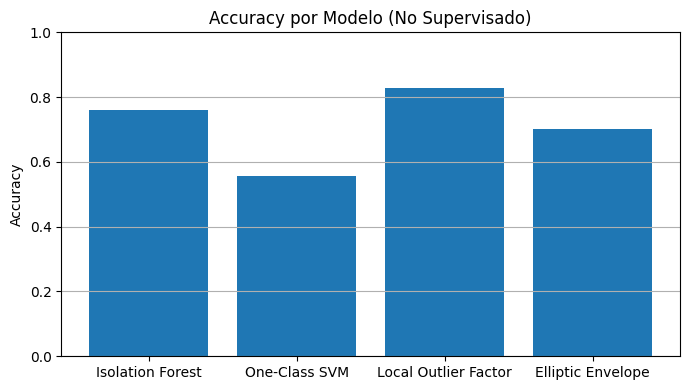

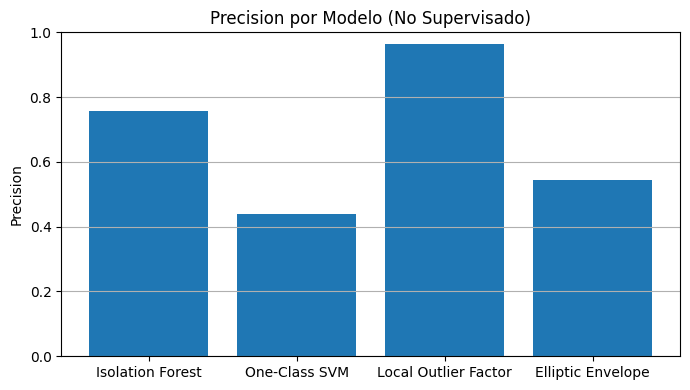

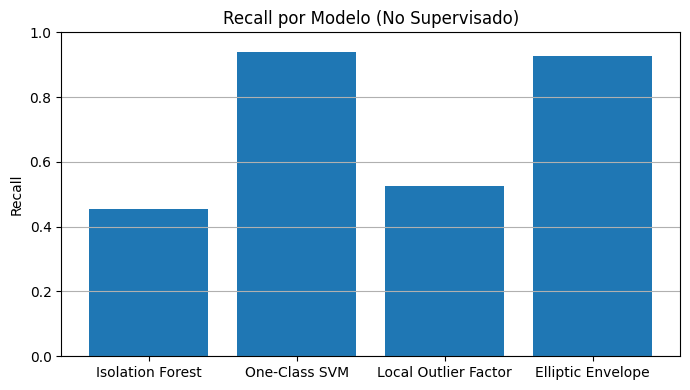

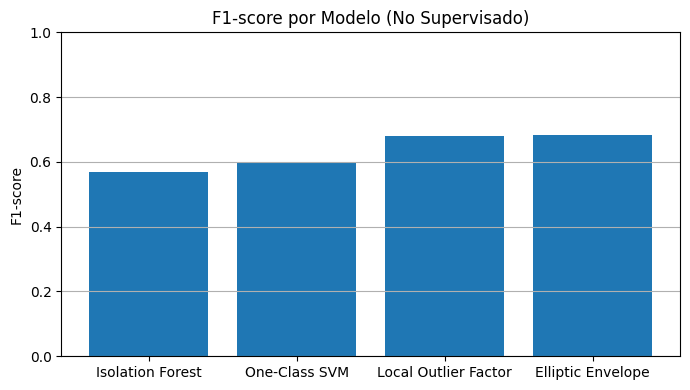

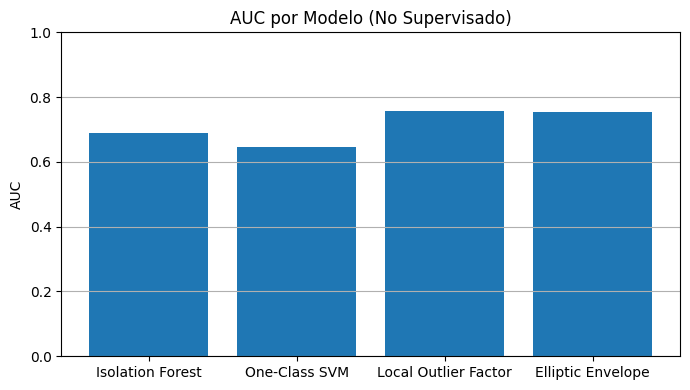

In [ ]:
#Forma antigua de evaluar los modelos, con solo 1 evaluacion

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt


# Almacenar resultados
model_names = []
accuracy = []
precision = []
recall = []
f1 = []
auc = []

# Evaluación unificada
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print(classification_report(y_true, y_pred, digits=4))

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1s = f1_score(y_true, y_pred, zero_division=0)
    auc_ = roc_auc_score(y_true, y_pred)

    # Guardar para gráfica
    model_names.append(model_name)
    accuracy.append(acc)
    precision.append(prec)
    recall.append(rec)
    f1.append(f1s)
    auc.append(auc_)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1s:.4f}")
    print(f"AUC      : {auc_:.4f}")

# -------------------------
# Evaluación final
# -------------------------

X_test_unsup = X_test_unsup.drop(columns=['category'], errors='ignore')

# Isolation Forest
best_iso = IsolationForest(n_estimators=206,max_samples= 0.8016,contamination=0.0818,max_features=0.1983, random_state=26)
best_iso.fit(benigno_trainNS)
pred_iso = [0 if p == 1 else 1 for p in best_iso.predict(X_test_unsup)]
evaluate_model(y_test_unsup, pred_iso, "Isolation Forest")

# One-Class SVM
best_ocsvm = OneClassSVM(kernel='poly', gamma='auto', nu =0.3447)
best_ocsvm.fit(benigno_trainNS)
pred_ocsvm = [0 if p == 1 else 1 for p in best_ocsvm.predict(X_test_unsup)]
evaluate_model(y_test_unsup, pred_ocsvm, "One-Class SVM")

# Local Outlier Factor
best_lof = LocalOutlierFactor(n_neighbors=6,leaf_size=31,contamination=0.01005,algorithm='ball_tree',novelty=True)
best_lof.fit(benigno_trainNS)
pred_lof = [0 if p == 1 else 1 for p in best_lof.predict(X_test_unsup)]
evaluate_model(y_test_unsup, pred_lof, "Local Outlier Factor")

# Elliptic Envelope
best_elliptic = EllipticEnvelope(contamination=0.4205,support_fraction=0.9805, random_state=26)
best_elliptic.fit(benigno_trainNS)
pred_elliptic = [0 if p == 1 else 1 for p in best_elliptic.predict(X_test_unsup)]
evaluate_model(y_test_unsup, pred_elliptic, "Elliptic Envelope")

# -------------------------
# Visualización de métricas
# -------------------------

metrics = [accuracy, precision, recall, f1, auc]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']

for metric, name in zip(metrics, metric_names):
    plt.figure(figsize=(7, 4))
    plt.bar(model_names, metric)
    plt.title(f'{name} por Modelo (No Supervisado)')
    plt.ylabel(name)
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


Se crean las instancias para aplicar la validación cruzada dentro de los modelos, para ello se necesita ocupar los hiperparametros obtenidos previamente y seleccionar nuevos sub conjuntos de evaluacion de manera iterativa.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
import pandas as pd
import numpy as np
import time

# Ajuste con los hiperparametros
# Se realizan entrenamientos con los mejores parametros encontrados en optune


#Mejores hiperparámetros Isolation Forest: {'n_estimators': 206, 'max_samples': 0.8015844296658571, 'contamination': 0.08176132105083248, 'max_features': 0.19827675035212922}

#Mejores hiperparámetros OCSVM: {'nu': 0.3446965076028471, 'gamma': 'auto', 'kernel': 'poly'}

#Mejores hiperparámetros LOF: {'n_neighbors': 6, 'leaf_size': 31, 'contamination': 0.010046732722538781, 'algorithm': 'ball_tree'}

#Mejores hiperparámetros EE: {'contamination': 0.42046515100671983, 'support_fraction': 0.9804796488315807}





models = {
    "Isolation Forest": lambda: IsolationForest(
        n_estimators=206, max_samples=0.80158, contamination=0.081761321,
        max_features=0.1982, random_state=26
    ),
    "One-Class SVM": lambda: OneClassSVM(
        kernel='poly', gamma='auto', nu=0.3446965076028471
    ),
    "Local Outlier Factor": lambda: LocalOutlierFactor(
        n_neighbors=6, leaf_size=31, contamination=0.01047,
        algorithm='ball_tree', novelty=True
    ),
    "Elliptic Envelope": lambda: EllipticEnvelope(
        contamination=0.42046, support_fraction=0.98047, random_state=26
    )
}


# Almacenar resultados por iteración
wide_format_results = []

for i in range(10):
    print(f"\n--- Iteración {i+1}/10 ---")
    sampled_train = benigno_trainNS.sample(frac=0.8, random_state=42 + i)

    row = {}
    for name, constructor in models.items():
        model = constructor()

        # Tiempo de entrenamiento
        start_train = time.time()
        model.fit(sampled_train)
        end_train = time.time()
        train_time = end_train - start_train

        # Tiempo de predicción
        start_pred = time.time()
        pred = model.predict(X_test_unsup)
        end_pred = time.time()
        predict_time = end_pred - start_pred

        # Convertir etiquetas: 1 → 0 (normal), -1 → 1 (anómalo)
        pred = [0 if p == 1 else 1 for p in pred]

        acc = accuracy_score(y_test_unsup, pred)
        prec = precision_score(y_test_unsup, pred, zero_division=0)
        rec = recall_score(y_test_unsup, pred, zero_division=0)
        f1s = f1_score(y_test_unsup, pred, zero_division=0)
        auc_ = roc_auc_score(y_test_unsup, pred)

        # Calcular TP, TN, FP, FN si es binario
        if len(np.unique(y_test_unsup)) == 2:
            tn, fp, fn, tp = confusion_matrix(y_test_unsup, pred).ravel()
        else:
            tn = fp = fn = tp = np.nan

        # Guardar métricas
        row[f'accuracy_{name}'] = acc
        row[f'precision_{name}'] = prec
        row[f'recall_{name}'] = rec
        row[f'f1_score_{name}'] = f1s
        row[f'auc_{name}'] = auc_
        row[f'TP_{name}'] = tp
        row[f'TN_{name}'] = tn
        row[f'FP_{name}'] = fp
        row[f'FN_{name}'] = fn
        row[f'train_time_{name}'] = train_time
        row[f'predict_time_{name}'] = predict_time

    wide_format_results.append(row)

# Crear DataFrame final
df_unsup_wide = pd.DataFrame(wide_format_results)

# Guardar CSV
csv_path = "/content/resultados_unsupervisados_tiempos.csv"
df_unsup_wide.to_csv(csv_path, index=False)

# Descargar CSV
from google.colab import files
files.download(csv_path)




--- Iteración 1/10 ---


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



--- Iteración 2/10 ---


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



--- Iteración 3/10 ---


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-168.615874587929852 > -169.292714761044635). You may want to try with a higher value of support_fraction (current value: 0.983).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-169.271762482460701 > -169.807471048498712). You may want to try with a higher value of support_fraction (current value: 0.983).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not h


--- Iteración 10/10 ---


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Descargar CSV
from google.colab import files
files.download(csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>